In [ ]:
 %pip install -q diffusers

In [ ]:
import torch
import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


<ipython-input-8-bebe1c2fa407>:15: RuntimeWarning: divide by zero encountered in divide
  return np.log(gamma_t / (1 - gamma_t))
<ipython-input-8-bebe1c2fa407>:15: RuntimeWarning: divide by zero encountered in log
  return np.log(gamma_t / (1 - gamma_t))


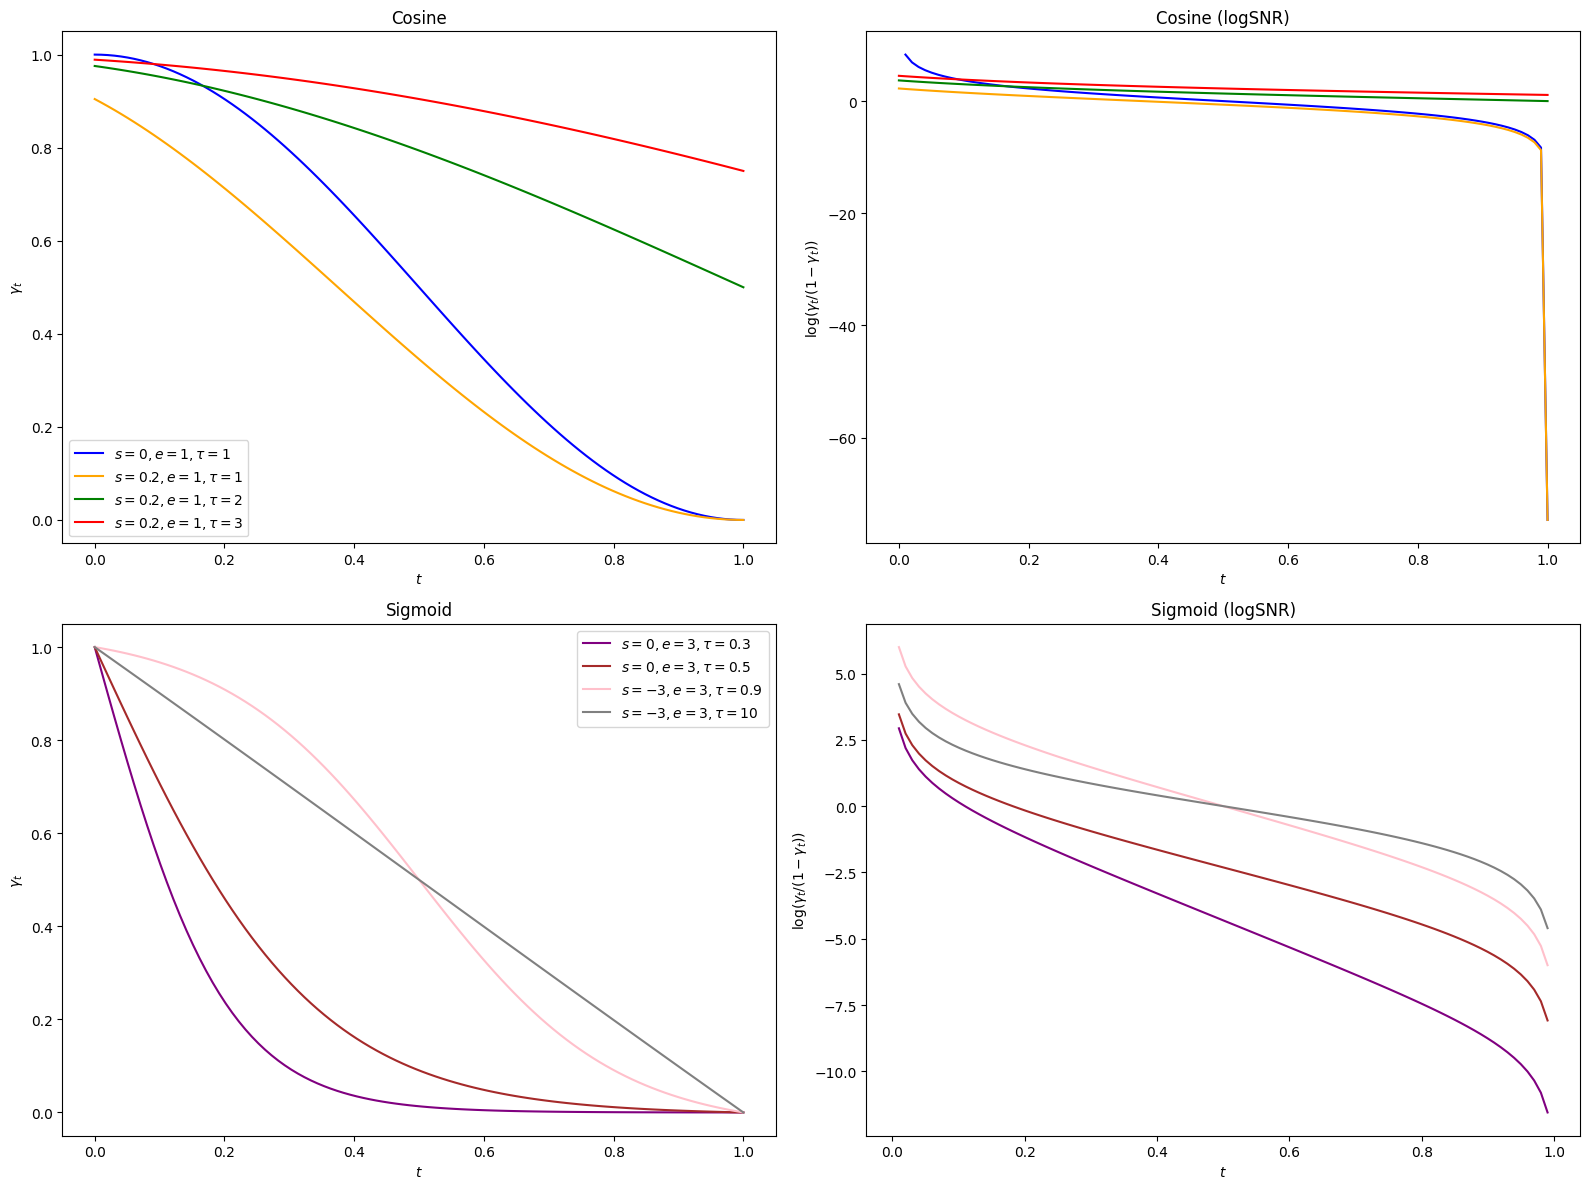

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the functions
def gamma_cosine(t, s, e, tau):
    return np.cos((t * (e - s) + s) / tau * (np.pi / 2)) ** 2

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def gamma_sigmoid(t, s, e, tau):
    return (sigmoid((t * (e - s) + s) / tau) - sigmoid(e / tau)) / (sigmoid(s / tau) - sigmoid(e / tau))

def logSNR(gamma_t):
    return np.log(gamma_t / (1 - gamma_t))

# Parameters for the plots
s_values = [0, 0.2, 0.2, 0.2, 0, 0, -3, -3]
e_values = [1, 1, 1, 1, 3, 3, 3, 3]
tau_values = [1, 1, 2, 3, 0.3, 0.5, 0.9, 10]
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

# Create timesteps
t = np.linspace(0, 1, 100)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# Plot Cosine-based schedules
for i in range(4):
    gamma_t = gamma_cosine(t, s_values[i], e_values[i], tau_values[i])
    axs[0, 0].plot(t, gamma_t, label=fr'$s={s_values[i]}, e={e_values[i]}, \tau={tau_values[i]}$', color=colors[i])
    axs[0, 1].plot(t, logSNR(gamma_t), color=colors[i])

axs[0, 0].set_title('Cosine')
axs[0, 0].set_xlabel('$t$')
axs[0, 0].set_ylabel('$\\gamma_t$')
axs[0, 0].legend()

axs[0, 1].set_title('Cosine (logSNR)')
axs[0, 1].set_xlabel('$t$')
axs[0, 1].set_ylabel('$\\log(\\gamma_t/(1-\\gamma_t))$')

# Plot Sigmoid-based schedules
for i in range(4, 8):
    gamma_t = gamma_sigmoid(t, s_values[i], e_values[i], tau_values[i])
    axs[1, 0].plot(t, gamma_t, label=fr'$s={s_values[i]}, e={e_values[i]}, \tau={tau_values[i]}$', color=colors[i])
    axs[1, 1].plot(t, logSNR(gamma_t), color=colors[i])

axs[1, 0].set_title('Sigmoid')
axs[1, 0].set_xlabel('$t$')
axs[1, 0].set_ylabel('$\\gamma_t$')
axs[1, 0].legend()

axs[1, 1].set_title('Sigmoid (logSNR)')
axs[1, 1].set_xlabel('$t$')
axs[1, 1].set_ylabel('$\\log(\\gamma_t/(1-\\gamma_t))$')

plt.tight_layout()
plt.show()


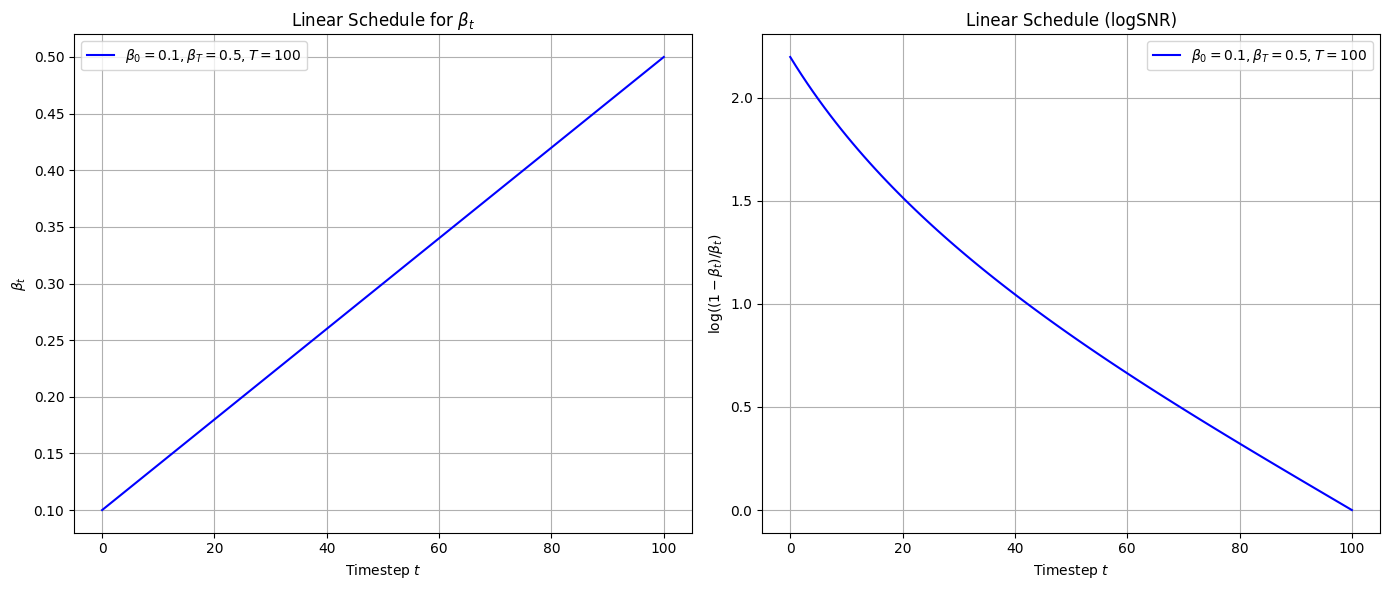

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the linear schedule function
def beta_linear(t, beta_0, beta_T, T):
    return beta_0 + (t / T) * (beta_T - beta_0)

# Define the logSNR function
def logSNR(beta_t):
    return np.log(1 - beta_t) - np.log(beta_t)

# Parameters for the linear schedule
beta_0 = 0.1  # Initial noise level
beta_T = 0.5  # Final noise level
T = 100  # Total number of timesteps

# Create timesteps
t = np.linspace(0, T, 100)

# Calculate beta_t for each timestep
beta_t = beta_linear(t, beta_0, beta_T, T)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Linear schedule
axs[0].plot(t, beta_t, label=fr'$\beta_0={beta_0}, \beta_T={beta_T}, T={T}$', color='blue')
axs[0].set_title('Linear Schedule for $\\beta_t$')
axs[0].set_xlabel('Timestep $t$')
axs[0].set_ylabel('$\\beta_t$')
axs[0].legend()
axs[0].grid(True)

# Plot Linear (logSNR)
axs[1].plot(t, logSNR(beta_t), label=fr'$\beta_0={beta_0}, \beta_T={beta_T}, T={T}$', color='blue')
axs[1].set_title('Linear Schedule (logSNR)')
axs[1].set_xlabel('Timestep $t$')
axs[1].set_ylabel('$\\log((1-\\beta_t)/\\beta_t)$')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True, transform=torchvision.transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 135MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 17.6MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 72.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]


In [ ]:
train_dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

Input shape: torch.Size([8, 1, 28, 28])
Labels: tensor([3, 9, 3, 1, 3, 6, 5, 5])


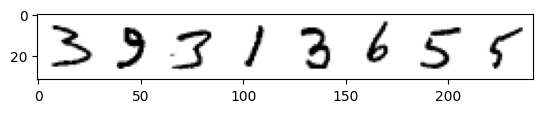

In [ ]:
x, y = next(iter(train_dataloader))
print("Input shape:", x.shape)
print("Labels:", y)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

In [ ]:
def corrupt(x, amount):
    """Corrupt the input `x` by mixing it with noise according to `amount`"""
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)  # Sort shape so broadcasting works
    return x * (1 - amount) + noise * amount

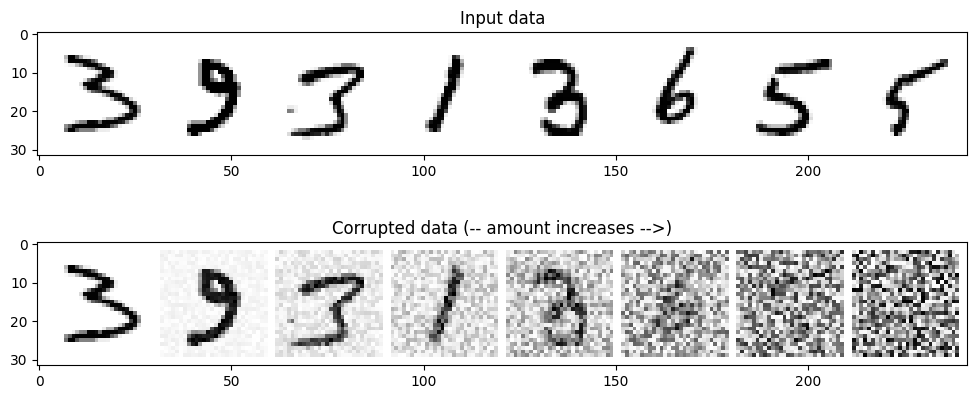

In [ ]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title("Input data")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

# Adding noise
amount = torch.linspace(0, 1, x.shape[0])  # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title("Corrupted data (-- amount increases -->)")
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap="Greys")

In [ ]:
class BasicUNet(nn.Module):
    """A minimal UNet implementation."""

    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.down_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(in_channels, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
            ]
        )
        self.up_layers = torch.nn.ModuleList(
            [
                nn.Conv2d(64, 64, kernel_size=5, padding=2),
                nn.Conv2d(64, 32, kernel_size=5, padding=2),
                nn.Conv2d(32, out_channels, kernel_size=5, padding=2),
            ]
        )
        self.act = nn.SiLU()  # The activation function
        self.downscale = nn.MaxPool2d(2)
        self.upscale = nn.Upsample(scale_factor=2)

    def forward(self, x):
        h = []
        for i, l in enumerate(self.down_layers):
            x = self.act(l(x))  # Through the layer and the activation function
            if i < 2:  # For all but the third (final) down layer:
                h.append(x)  # Storing output for skip connection
                x = self.downscale(x)  # Downscale ready for the next layer

        for i, l in enumerate(self.up_layers):
            if i > 0:  # For all except the first up layer
                x = self.upscale(x)  # Upscale
                x += h.pop()  # Fetching stored output (skip connection)
            x = self.act(l(x))  # Through the layer and the activation function

        return x

In [ ]:
net = BasicUNet()
x = torch.rand(8, 1, 28, 28)
net(x).shape

torch.Size([8, 1, 28, 28])

In [ ]:
sum([p.numel() for p in net.parameters()])

309057

In [ ]:
model = UNet2DModel(
    sample_size=28,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64),  # Roughly matching our basic unet example
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)


In [ ]:
sum([p.numel() for p in model.parameters()])  # 1.7M vs the ~309k parameters of the BasicUNet

1707009

In [ ]:
# @markdown Trying UNet2DModel instead of BasicUNet:

# Dataloader (you can mess with batch size)
batch_size = 128
train_dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# How many runs through the data should we do?
n_epochs = 3

# Create the network
net = UNet2DModel(
    sample_size=28,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(32, 64, 64),  # Roughly matching our basic unet example
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)  # <<<
net.to(device)

# Our loss finction
loss_fn = nn.MSELoss()

# The optimizer
opt = torch.optim.Adam(net.parameters(), lr=1e-3)

# Keeping a record of the losses for later viewing
losses = []

# The training loop
for epoch in range(n_epochs):

    for x, y in train_dataloader:

        # Get some data and prepare the corrupted version
        x = x.to(device)  # Data on the GPU
        noise_amount = torch.rand(x.shape[0]).to(device)  # Pick random noise amounts
        noisy_x = corrupt(x, noise_amount)  # Create our noisy x

        # Get the model prediction
        pred = net(noisy_x, 0).sample  # <<< Using timestep 0 always, adding .sample

        # Calculate the loss
        loss = loss_fn(pred, x)  # How close is the output to the true 'clean' x?

        # Backprop and update the params:
        opt.zero_grad()
        loss.backward()
        opt.step()

        # Store the loss for later
        losses.append(loss.item())

    # Print our the average of the loss values for this epoch:
    avg_loss = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
    print(f"Finished epoch {epoch}. Average loss for this epoch: {avg_loss:05f}")

# Plot losses and some samples
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Losses
axs[0].plot(losses)
axs[0].set_ylim(0, 0.1)
axs[0].set_title("Loss over time")

# Samples
n_steps = 40
x = torch.rand(64, 1, 28, 28).to(device)
for i in range(n_steps):
    noise_amount = torch.ones((x.shape[0],)).to(device) * (1 - (i / n_steps))  # Starting high going low
    with torch.no_grad():
        pred = net(x, 0).sample
    mix_factor = 1 / (n_steps - i)
    x = x * (1 - mix_factor) + pred * mix_factor

axs[1].imshow(torchvision.utils.make_grid(x.detach().cpu(), nrow=8)[0].clip(0, 1), cmap="Greys")
axs[1].set_title("Generated Samples")

KeyboardInterrupt: 

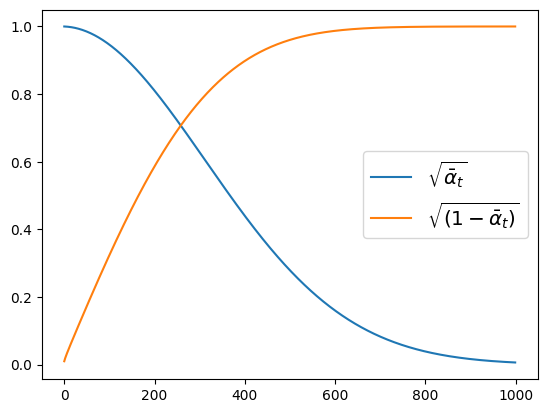

In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

visualize the DDPM noising process for different timesteps:

X shape torch.Size([8, 1, 28, 28])
Noisy X shape torch.Size([8, 1, 28, 28])


Text(0.5, 1.0, 'Noisy X')

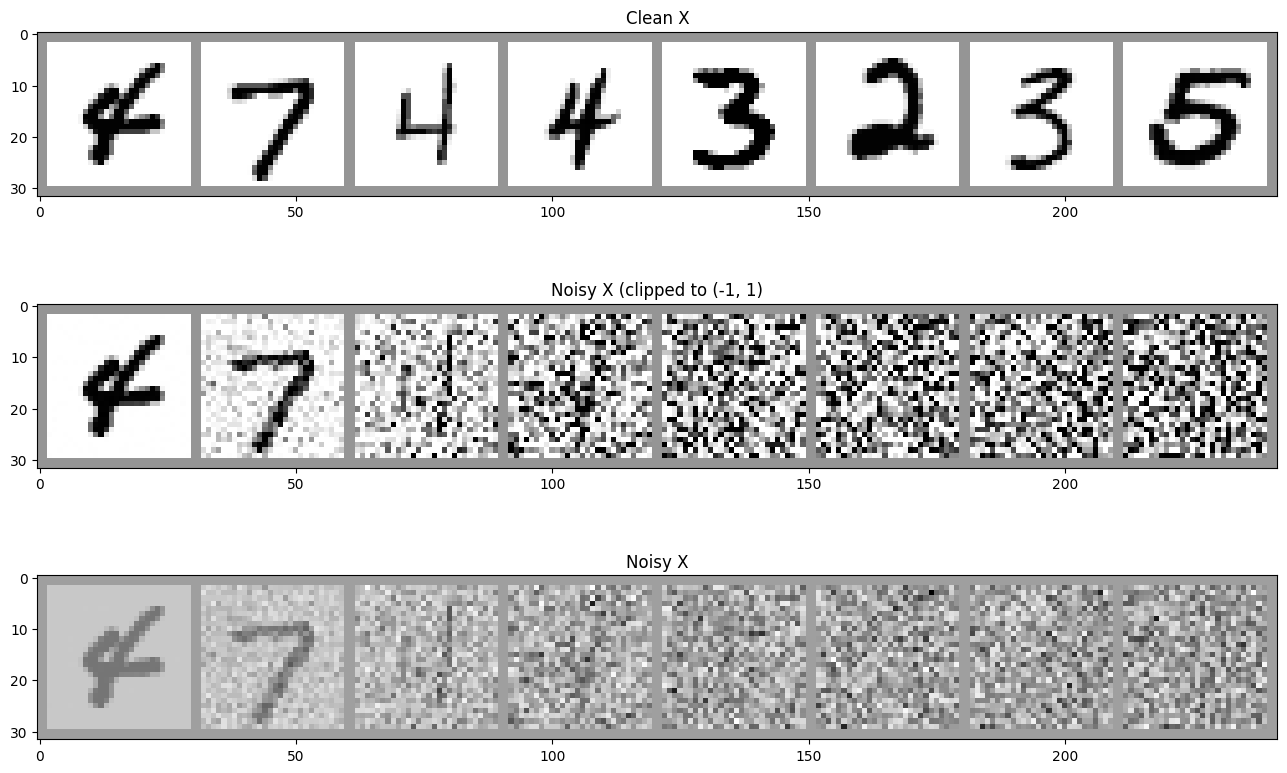

In [ ]:


# Noise a batch of images to view the effect
fig, axs = plt.subplots(3, 1, figsize=(16, 10))
xb, yb = next(iter(train_dataloader))
xb = xb.to(device)[:8]
xb = xb * 2.0 - 1.0  # Map to (-1, 1)
print("X shape", xb.shape)

# Show clean inputs
axs[0].imshow(torchvision.utils.make_grid(xb[:8])[0].detach().cpu(), cmap="Greys")
axs[0].set_title("Clean X")

# Add noise with scheduler
timesteps = torch.linspace(0, 999, 8).long().to(device)
noise = torch.randn_like(xb)  # << NB: randn not rand
noisy_xb = noise_scheduler.add_noise(xb, noise, timesteps)
print("Noisy X shape", noisy_xb.shape)

# Show noisy version (with and without clipping)
axs[1].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu().clip(-1, 1), cmap="Greys")
axs[1].set_title("Noisy X (clipped to (-1, 1)")
axs[2].imshow(torchvision.utils.make_grid(noisy_xb[:8])[0].detach().cpu(), cmap="Greys")
axs[2].set_title("Noisy X")

In [ ]:
noise = torch.randn_like(xb) # << NB: randn not rand
noisy_x = noise_scheduler.add_noise(x, noise, timesteps)
model_prediction = model(noisy_x, timesteps).sample
loss = mse_loss(model_prediction, noise) # noise as the target

RuntimeError: The size of tensor a (8) must match the size of tensor b (128) at non-singleton dimension 0

Using device: cpu


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/5, Avg Loss: 0.10403
Epoch 2/5, Avg Loss: 0.04150
Epoch 3/5, Avg Loss: 0.03489
Epoch 4/5, Avg Loss: 0.03180
Epoch 5/5, Avg Loss: 0.02994


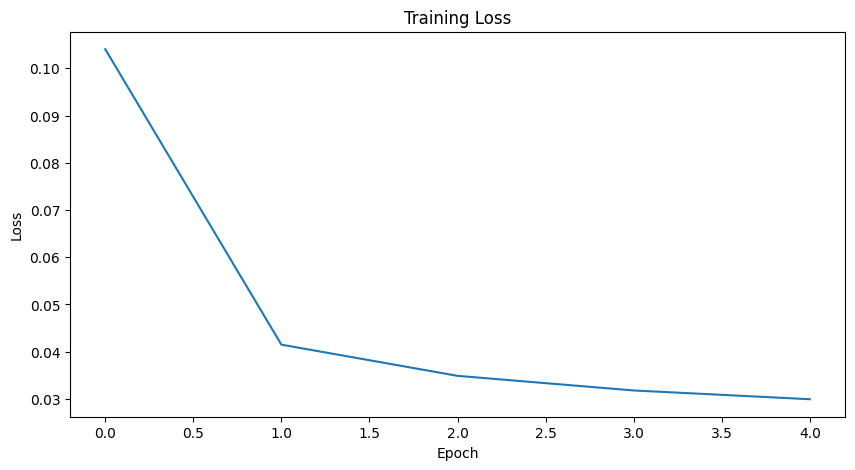

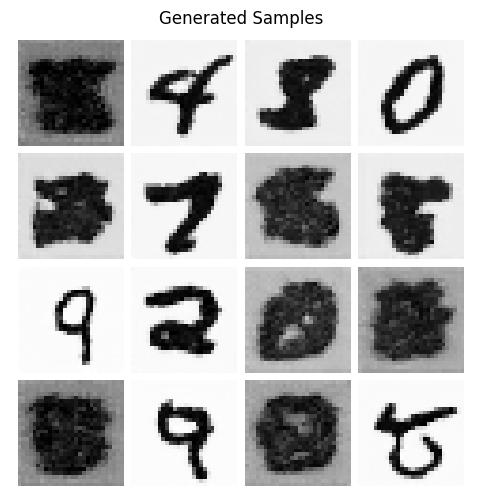

In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset and dataloader
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # scale to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Model definition (standard DDPM-compatible UNet)
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# DDPM noise scheduler
noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 5
losses = []

for epoch in range(epochs):
    epoch_losses = []

    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Sample random timestep for each image in batch
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps,
                                  (batch.size(0),), device=device).long()

        # Generate random noise
        noise = torch.randn_like(batch)

        # Corrupt images with noise scheduler
        noisy_batch = noise_scheduler.add_noise(batch, noise, timesteps)

        # Predict the noise
        noise_pred = model(noisy_batch, timesteps).sample

        # Compute MSE loss between predicted and true noise
        loss = nn.functional.mse_loss(noise_pred, noise)

        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Generation using DDPM sampling
model.eval()
num_samples = 16
img = torch.randn(num_samples, 1, 28, 28, device=device)

for i, t in enumerate(noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(img, t).sample
    img = noise_scheduler.step(pred_noise, t, img).prev_sample

# Display generated samples
img = (img.clamp(-1, 1) + 1) / 2  # Rescale back to [0, 1] for display
grid = torchvision.utils.make_grid(img.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/Diffusion/ddpm_5ep_number_generator.pt")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

class DiffusionModel(nn.Module):
    """
    DiffusionModel implements a diffusion-based generative model based on the principles of Diffusion Probabilistic Models (DDPMs).

    Forward Pass (Noise Addition):
        Systematically corrupts images by gradually adding Gaussian noise based on a predetermined schedule.

    Reverse Pass (Denoising):
        Iteratively removes noise from images, conditioned on a learned neural network, to reconstruct clean images.

    Attributes:
        model: UNet2DModel neural network predicting noise.
        noise_scheduler: DDPM noise scheduler managing noise addition and removal.
    """

    def __init__(self, sample_size, in_channels=1, out_channels=1, noise_scheduler):
        super().__init__()
        self.model = UNet2DModel(
            sample_size=sample_size,
            in_channels=in_channels,
            out_channels=out_channels,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=(
                "DownBlock2D",
                "AttnDownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
            ),
        )
        self.noise_scheduler = DDPMScheduler(noise_scheduler, num_train_timesteps=1000)

    def forward(self, noisy_images, timesteps):
        """
        Predicts the noise given noisy images and timesteps.

        Args:
            noisy_images (torch.Tensor): Noisy input images.
            timesteps (torch.Tensor): Timestep indices for each image in the batch.

        Returns:
            torch.Tensor: Predicted noise.
        """
        return self.model(noisy_images, timesteps).sample

# Dataset preparation
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # Scale images to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Initialize the Diffusion Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DiffusionModel(sample_size=28).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_losses = []

    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Randomly sample timesteps for each image in the batch
        timesteps = torch.randint(0, model.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()

        # Generate random Gaussian noise
        noise = torch.randn_like(batch)

        # Corrupt images according to the diffusion process
        noisy_images = model.noise_scheduler.add_noise(batch, noise, timesteps)

        # Predict the noise using the neural network
        predicted_noise = model(noisy_images, timesteps)

        # Compute loss (denoising objective)
        loss = nn.functional.mse_loss(predicted_noise, noise)

        # Optimization step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_epoch_loss:.6f}")

# Generate samples
model.eval()
num_samples = 16
sample = torch.randn(num_samples, 1, 28, 28, device=device)
for t in reversed(model.noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(sample, t)
    sample = model.noise_scheduler.step(pred_noise, t, sample).prev_sample

# Visualize generated images
sample = (sample.clamp(-1, 1) + 1) / 2  # Scale images back to [0, 1]
grid = torchvision.utils.make_grid(sample.cpu(), nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis('off')
plt.title("Generated Samples from Diffusion Model")
plt.show()


100%|██████████| 9.91M/9.91M [00:00<00:00, 42.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.25MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.33MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.22MB/s]
/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch [1/5], Average Loss: 0.129857
Epoch [2/5], Average Loss: 0.063699
Epoch [3/5], Average Loss: 0.054516
Epoch [4/5], Average Loss: 0.050905
Epoch [5/5], Average Loss: 0.048414


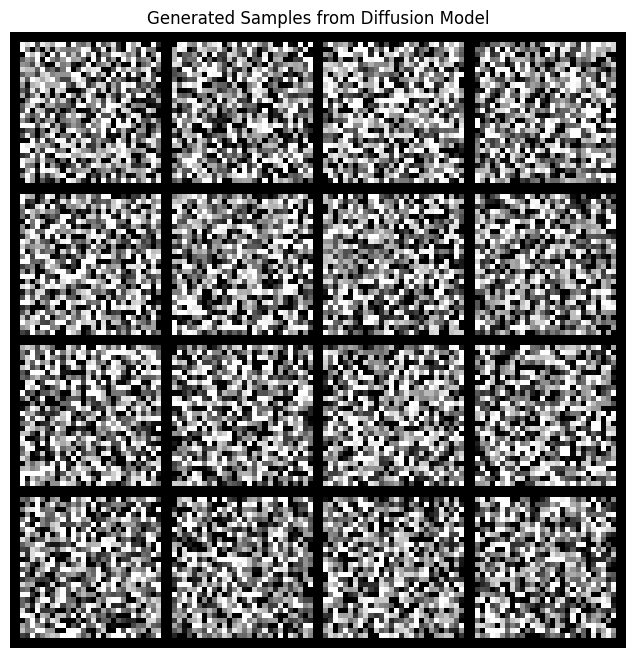

In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

class DiffusionModel(nn.Module):
    """
    DiffusionModel implements a diffusion-based generative model based on the principles of Diffusion Probabilistic Models (DDPMs).

    Forward Pass (Noise Addition):
        Systematically corrupts images by gradually adding Gaussian noise based on a predetermined schedule.

    Reverse Pass (Denoising):
        Iteratively removes noise from images, conditioned on a learned neural network, to reconstruct clean images.

    The reverse process is learned to approximate the true posterior via noise prediction.
    The model uses a simplified loss based on score-matching, which regresses the noise added at each step.

    Attributes:
        model: UNet2DModel neural network predicting noise.
        noise_scheduler: DDPM noise scheduler managing noise addition and removal.
    """

    def __init__(self, sample_size, in_channels=1, out_channels=1):
        super().__init__()
        self.model = UNet2DModel(
            sample_size=sample_size,
            in_channels=in_channels,
            out_channels=out_channels,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=(
                "DownBlock2D",
                "AttnDownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "AttnUpBlock2D",
                "UpBlock2D",
            ),
        )
        self.noise_scheduler = DDPMScheduler(beta_schedule="squaredcos_cap_v2", num_train_timesteps=1000)
        """
        Noise scheduling is critical in the forward process of DDPM.

        By default, the scheduler uses a linear schedule:
            beta_schedule = "linear"
            beta_start = 0.0001
            beta_end = 0.02

        Alternative schedules:
            - Cosine:    beta_schedule="squaredcos_cap_v2"
            - Scaled:    beta_schedule="scaled_linear"
            - Sigmoid:   beta_schedule="sigmoid"

        These schedules affect how much noise is added at each timestep t,
        influencing training stability and sample quality.
        """

    def forward(self, noisy_images, timesteps):
        """
        Predicts the noise given noisy images and timesteps.

        Args:
            noisy_images (torch.Tensor): Noisy input images.
            timesteps (torch.Tensor): Timestep indices for each image in the batch.

        Returns:
            torch.Tensor: Predicted noise.
        """
        return self.model(noisy_images, timesteps).sample

# Dataset preparation
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # Scale images to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Initialize the Diffusion Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DiffusionModel(sample_size=28).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
num_epochs = 5
losses = []
for epoch in range(num_epochs):
    epoch_loss = 0
    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Forward diffusion: sample timestep and add noise
        timesteps = torch.randint(0, model.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_images = model.noise_scheduler.add_noise(batch, noise, timesteps)

        # Reverse process: predict noise
        predicted_noise = model(noisy_images, timesteps)

        # Training loss based on noise prediction (denoising score matching loss)
        loss = nn.functional.mse_loss(predicted_noise, noise)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_epoch_loss = epoch_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_epoch_loss:.6f}")
    torch.save(model.state_dict(), f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_squaredcos_cap_v2_number_generator.pt")


# Generation: reverse diffusion starting from Gaussian noise
model.eval()
num_samples = 16
sample = torch.randn(num_samples, 1, 28, 28, device=device)

# The reverse diffusion process denoises the sample iteratively using the model's predictions
for t in reversed(model.noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(sample, t)
    sample = model.noise_scheduler.step(pred_noise, t, sample).prev_sample

# Post-process and visualize
sample = (sample.clamp(-1, 1) + 1) / 2  # Scale images back to [0, 1]
grid = torchvision.utils.make_grid(sample.cpu(), nrow=4)

plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
plt.axis('off')
plt.title("Generated Samples from Diffusion Model")
plt.show()


In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
from matplotlib import pyplot as plt

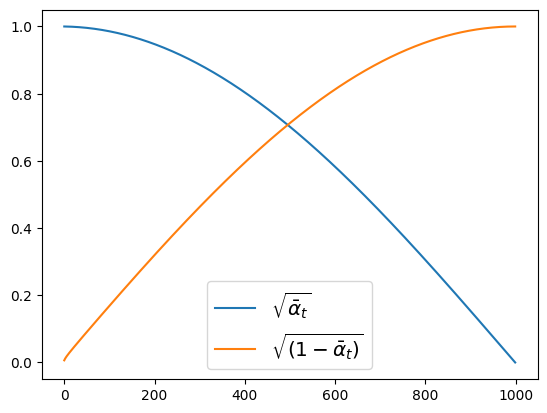

In [ ]:
noise_scheduler = DDPMScheduler(beta_schedule="squaredcos_cap_v2", num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

Using device: cpu
Epoch 1/5, Avg Loss: 0.12688
Epoch 2/5, Avg Loss: 0.06250
Epoch 3/5, Avg Loss: 0.05419
Epoch 4/5, Avg Loss: 0.05040
Epoch 5/5, Avg Loss: 0.04821


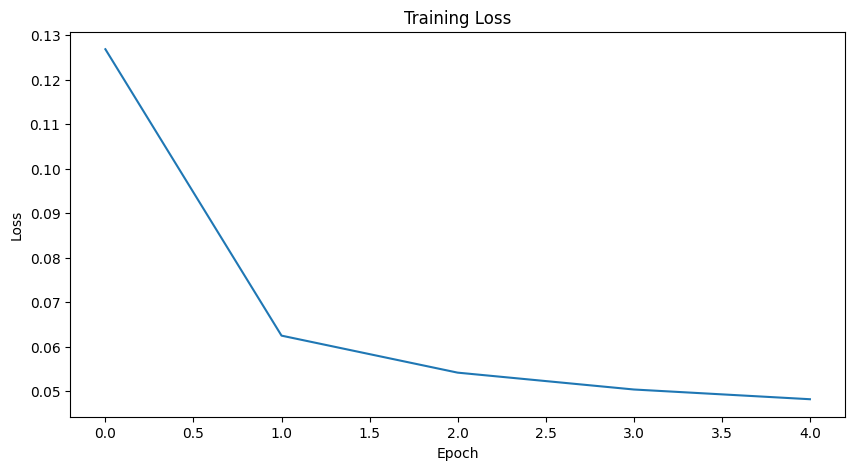

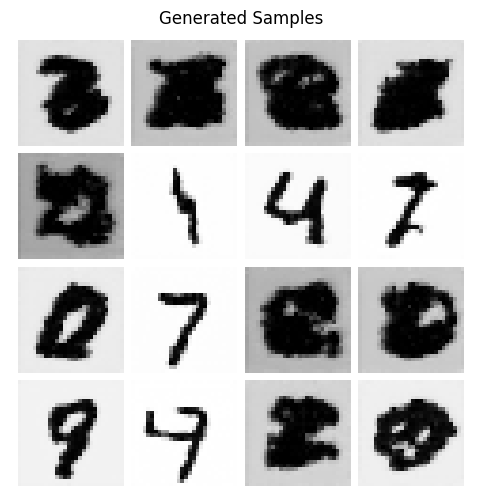

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset and dataloader
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # scale to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Model definition (standard DDPM-compatible UNet)
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# DDPM noise scheduler
noise_scheduler = DDPMScheduler(beta_schedule="squaredcos_cap_v2", num_train_timesteps=1000)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 5
losses = []

for epoch in range(epochs):
    epoch_losses = []

    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Sample random timestep for each image in batch
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps,
                                  (batch.size(0),), device=device).long()

        # Generate random noise
        noise = torch.randn_like(batch)

        # Corrupt images with noise scheduler
        noisy_batch = noise_scheduler.add_noise(batch, noise, timesteps)

        # Predict the noise
        noise_pred = model(noisy_batch, timesteps).sample

        # Compute MSE loss between predicted and true noise
        loss = nn.functional.mse_loss(noise_pred, noise)

        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")
    torch.save(model.state_dict(), f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_squaredcos_cap_v2_number_generator.pt")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Generation using DDPM sampling
model.eval()
num_samples = 16
img = torch.randn(num_samples, 1, 28, 28, device=device)

for i, t in enumerate(noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(img, t).sample
    img = noise_scheduler.step(pred_noise, t, img).prev_sample

# Display generated samples
img = (img.clamp(-1, 1) + 1) / 2  # Rescale back to [0, 1] for display
grid = torchvision.utils.make_grid(img.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


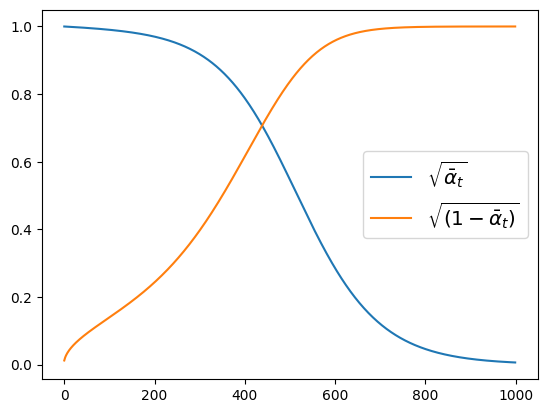

In [ ]:
noise_scheduler = DDPMScheduler(beta_schedule="sigmoid", num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

Using device: cpu
Epoch 1/5, Avg Loss: 0.12919
Epoch 2/5, Avg Loss: 0.05691
Epoch 3/5, Avg Loss: 0.04972
Epoch 4/5, Avg Loss: 0.04645
Epoch 5/5, Avg Loss: 0.04419


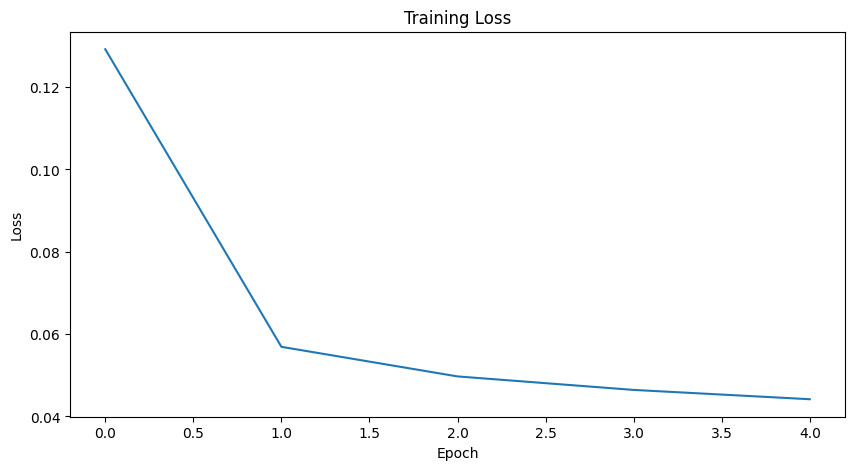

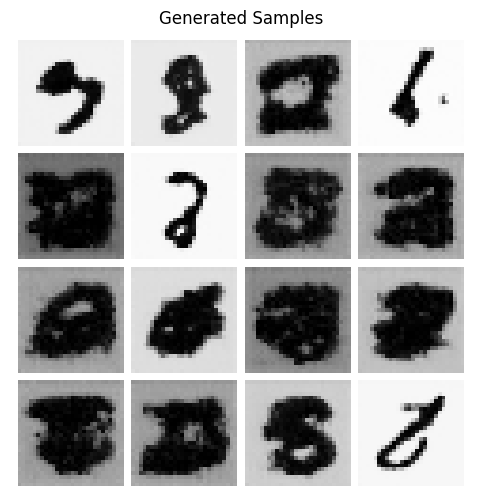

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset and dataloader
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # scale to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Model definition (standard DDPM-compatible UNet)
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# DDPM noise scheduler
noise_scheduler = DDPMScheduler(beta_schedule="sigmoid", num_train_timesteps=1000)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 5
losses = []

for epoch in range(epochs):
    epoch_losses = []

    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Sample random timestep for each image in batch
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps,
                                  (batch.size(0),), device=device).long()

        # Generate random noise
        noise = torch.randn_like(batch)

        # Corrupt images with noise scheduler
        noisy_batch = noise_scheduler.add_noise(batch, noise, timesteps)

        # Predict the noise
        noise_pred = model(noisy_batch, timesteps).sample

        # Compute MSE loss between predicted and true noise
        loss = nn.functional.mse_loss(noise_pred, noise)

        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")
    torch.save(model.state_dict(), f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_sigmoid_number_generator.pt")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Generation using DDPM sampling
model.eval()
num_samples = 16
img = torch.randn(num_samples, 1, 28, 28, device=device)

for i, t in enumerate(noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(img, t).sample
    img = noise_scheduler.step(pred_noise, t, img).prev_sample

# Display generated samples
img = (img.clamp(-1, 1) + 1) / 2  # Rescale back to [0, 1] for display
grid = torchvision.utils.make_grid(img.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


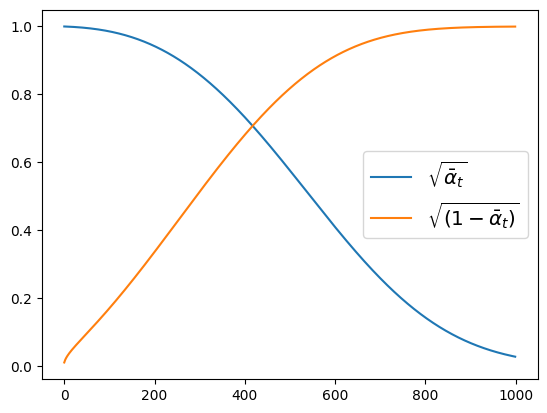

In [ ]:
noise_scheduler = DDPMScheduler(beta_schedule="scaled_linear", num_train_timesteps=1000)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.41MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.29MB/s]
/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/5, Avg Loss: 0.12866
Epoch 2/5, Avg Loss: 0.05653
Epoch 3/5, Avg Loss: 0.04883
Epoch 4/5, Avg Loss: 0.04554
Epoch 5/5, Avg Loss: 0.04303


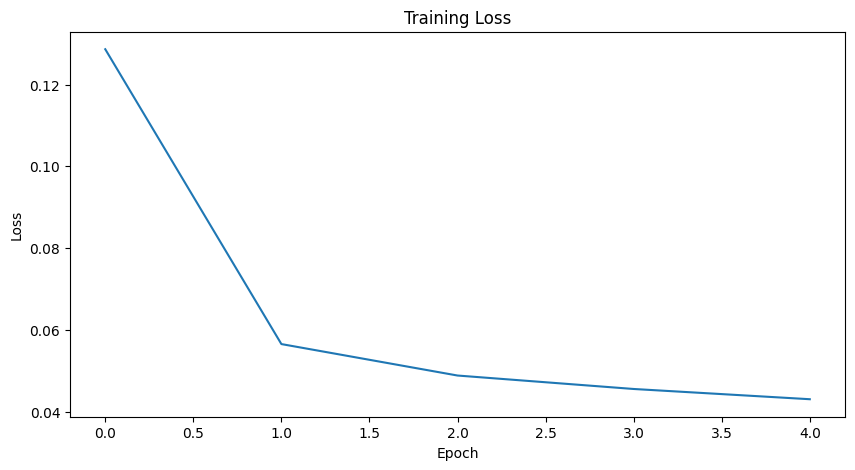

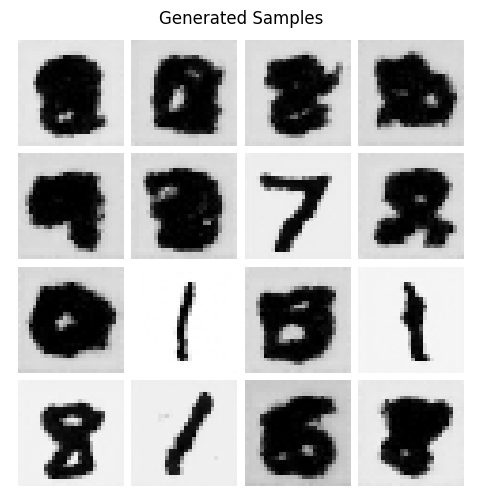

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Dataset and dataloader
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),  # scale to [-1,1]
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Model definition (standard DDPM-compatible UNet)
model = UNet2DModel(
    sample_size=28,
    in_channels=1,
    out_channels=1,
    layers_per_block=2,
    block_out_channels=(32, 64, 128),
    down_block_types=(
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
    ),
).to(device)

# DDPM noise scheduler
noise_scheduler = DDPMScheduler(beta_schedule="scaled_linear", num_train_timesteps=1000)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Training loop
epochs = 5
losses = []

for epoch in range(epochs):
    epoch_losses = []

    for batch, _ in train_dataloader:
        batch = batch.to(device)

        # Sample random timestep for each image in batch
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps,
                                  (batch.size(0),), device=device).long()

        # Generate random noise
        noise = torch.randn_like(batch)

        # Corrupt images with noise scheduler
        noisy_batch = noise_scheduler.add_noise(batch, noise, timesteps)

        # Predict the noise
        noise_pred = model(noisy_batch, timesteps).sample

        # Compute MSE loss between predicted and true noise
        loss = nn.functional.mse_loss(noise_pred, noise)

        # Backpropagation and optimizer step
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")
    torch.save(model.state_dict(), f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_scaled_linear_number_generator.pt")

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Generation using DDPM sampling
model.eval()
num_samples = 16
img = torch.randn(num_samples, 1, 28, 28, device=device)

for i, t in enumerate(noise_scheduler.timesteps):
    with torch.no_grad():
        pred_noise = model(img, t).sample
    img = noise_scheduler.step(pred_noise, t, img).prev_sample

# Display generated samples
img = (img.clamp(-1, 1) + 1) / 2  # Rescale back to [0, 1] for display
grid = torchvision.utils.make_grid(img.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


Using device: cpu
Epoch 1/1, Avg Loss: 0.10556


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `beta_schedule` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'beta_schedule' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.beta_schedule'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


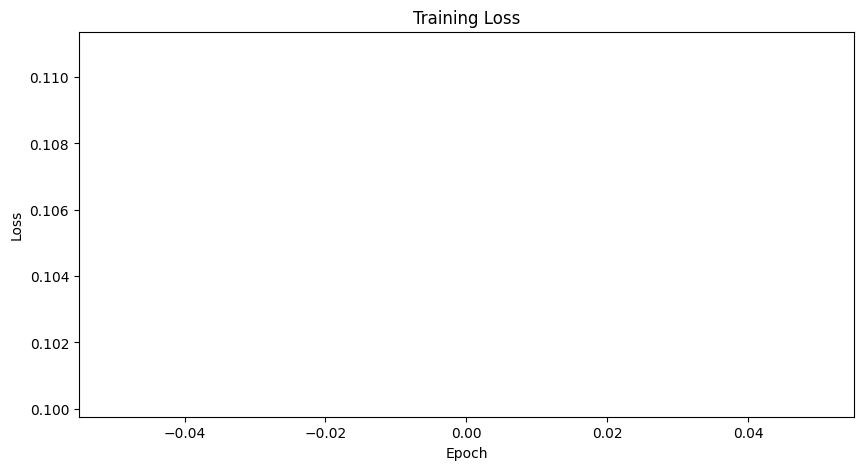

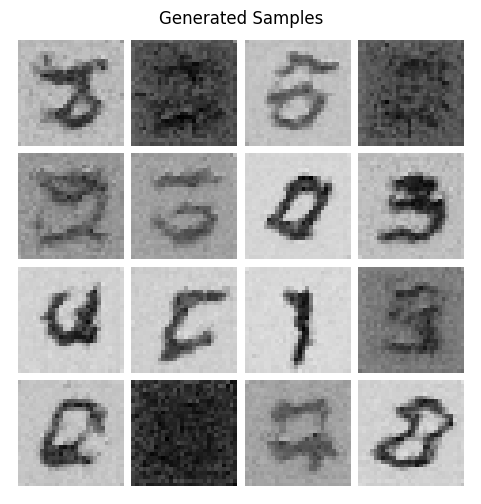

In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt

class DiffusionTrainer:
    """
    DiffusionModel implements a diffusion-based generative model based on the principles of Diffusion Probabilistic Models (DDPMs).

    Forward Pass (Noise Addition):
        Systematically corrupts images by gradually adding Gaussian noise based on a predetermined schedule.

    Reverse Pass (Denoising):
        Iteratively removes noise from images, conditioned on a learned neural network, to reconstruct clean images.

    The reverse process is learned to approximate the true posterior via noise prediction by training of a UNet neural network to predict added noise at any timestep

    Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            beta_schedule: The type of beta schedule used in the noise scheduler

        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {"beta_schedule": "squaredcos_cap_v2", "num_train_timesteps": 1000}

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        """
        Noise scheduling is critical in the forward process of DDPM.

        By default, the scheduler uses a linear schedule:
            beta_schedule = "linear"
            beta_start = 0.0001
            beta_end = 0.02

        Alternative schedules:
            - Cosine:    beta_schedule="squaredcos_cap_v2"
            - Scaled:    beta_schedule="scaled_linear"
            - Sigmoid:   beta_schedule="sigmoid"

        These schedules affect how much noise is added at each timestep t,
        influencing training stability and sample quality.
        """
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img

# Set up environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST dataset with normalization to [-1, 1]
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Define noise scheduler parameters
scheduler_params = {
    "beta_schedule": "linear",
    "num_train_timesteps": 1000
}

# Initialize trainer and train the model
trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params)
trainer.train(train_dataloader, epochs=1)

# Sample and visualize generated images
samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


In [ ]:
!pip install optuna

In [ ]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt
import optuna

class DiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img

def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

# Set up environment
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load MNIST dataset with normalization to [-1, 1]
dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

KeyboardInterrupt: 

# BEgining per bene


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 19.7 MB/s eta 0:00:00


In [ ]:
!pip install diffusers

In [ ]:
!pip install torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 100.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 113.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvj

In [ ]:
import torch
import torchvision
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from diffusers import DDPMScheduler, UNet2DModel
import matplotlib.pyplot as plt
import optuna

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:


class DiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=28,
            in_channels=1,
            out_channels=1,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for batch, _ in dataloader:
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_number_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 1, 28, 28, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    if scheduler_kwargs is None:
        scheduler_kwargs = {}
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()
import torchvision.transforms as T

def visualize_forward_diffusion(trainer, dataset, schedule_name, num_steps=8):
    """
    Visualize the forward diffusion process for an example image from the dataset.

    Args:
        trainer: A DiffusionTrainer instance (already configured with a specific noise schedule).
        dataset: The dataset to draw an example image from.
        schedule_name: The name of the noise schedule (for the plot title).
        num_steps: Number of timesteps to visualize (evenly spaced).
    """
    trainer.model.eval()
    noise_scheduler = trainer.noise_scheduler


    img, _ = dataset[0]
    img = img.unsqueeze(0).to(trainer.device)


    timesteps = torch.linspace(0, noise_scheduler.config.num_train_timesteps - 1, num_steps).long().to(trainer.device)


    plt.figure(figsize=(2.5 * num_steps, 2.5))

    for i, t in enumerate(timesteps):
        noise = torch.randn_like(img)
        noised_img = noise_scheduler.add_noise(img, noise, t)

        noised_img_vis = (noised_img[0].detach().cpu().clamp(-1, 1) + 1) / 2
        plt.subplot(1, num_steps, i + 1)
        if noised_img_vis.shape[0] == 1:
            plt.imshow(noised_img_vis[0], cmap="gray")
        else:
            plt.imshow(noised_img_vis.permute(1, 2, 0))
        plt.title(f"t={t.item()}")
        plt.axis("off")

    plt.suptitle(f"Forward Process — {schedule_name} Schedule", fontsize=16)
    plt.show()




In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset = torchvision.datasets.MNIST(
    root="mnist/", train=True, download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Lambda(lambda x: x * 2.0 - 1.0),
    ])
)
train_dataloader = DataLoader(dataset, batch_size=128, shuffle=True)



Using device: cuda


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.57MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.28MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.28MB/s]


In [ ]:
beta_schedules = ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]

Training with linear schedule


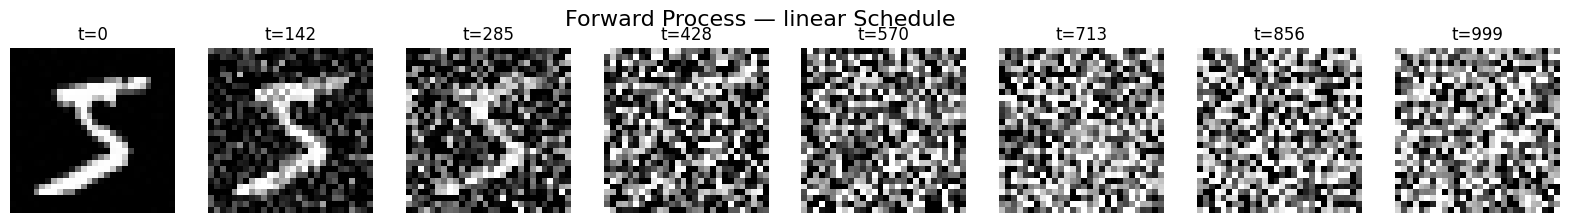

Training with scaled_linear schedule


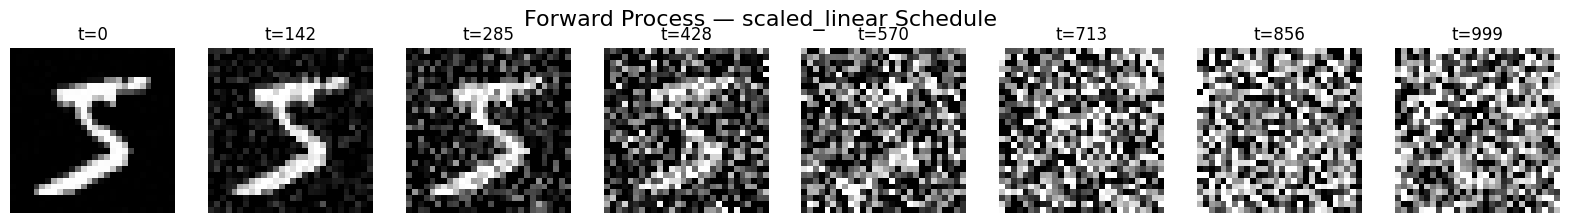

Training with squaredcos_cap_v2 schedule


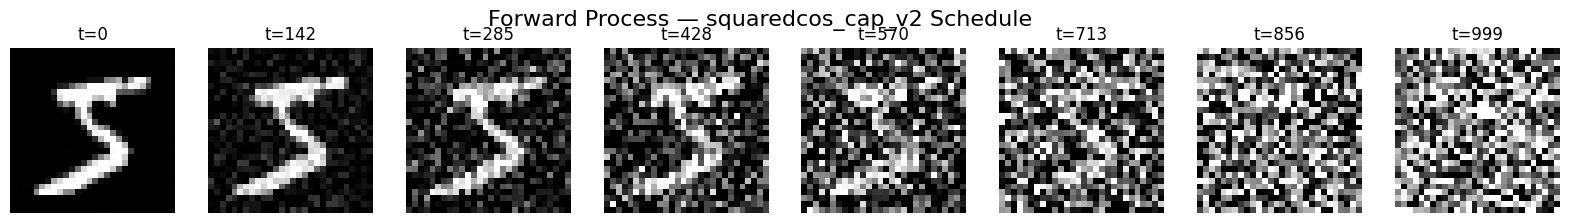

Training with sigmoid schedule


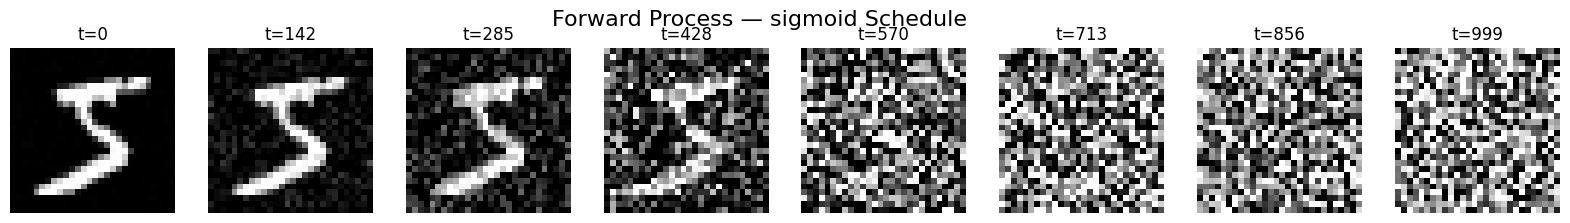

In [ ]:
for schedule in beta_schedules:
  print(f"Training with {schedule} schedule")
  scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }
  trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)
  visualize_forward_diffusion(trainer, dataset, schedule_name=trainer.noise_scheduler.config.beta_schedule, num_steps=8)

Training with linear schedule


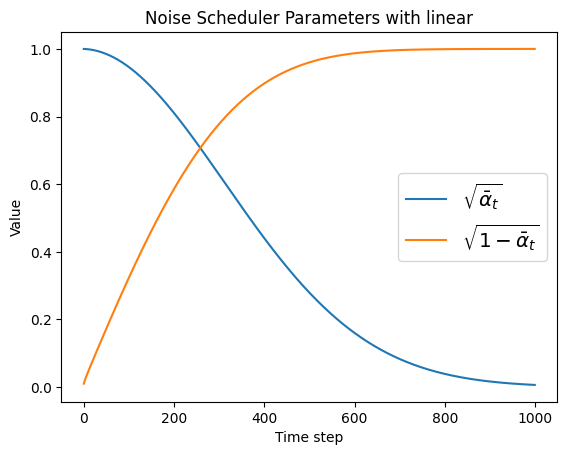

Epoch 1/10, Avg Loss: 0.09501
Epoch 2/10, Avg Loss: 0.04016
Epoch 3/10, Avg Loss: 0.03442
Epoch 4/10, Avg Loss: 0.03187
Epoch 5/10, Avg Loss: 0.03008
Epoch 6/10, Avg Loss: 0.02902
Epoch 7/10, Avg Loss: 0.02798
Epoch 8/10, Avg Loss: 0.02743
Epoch 9/10, Avg Loss: 0.02655
Epoch 10/10, Avg Loss: 0.02575


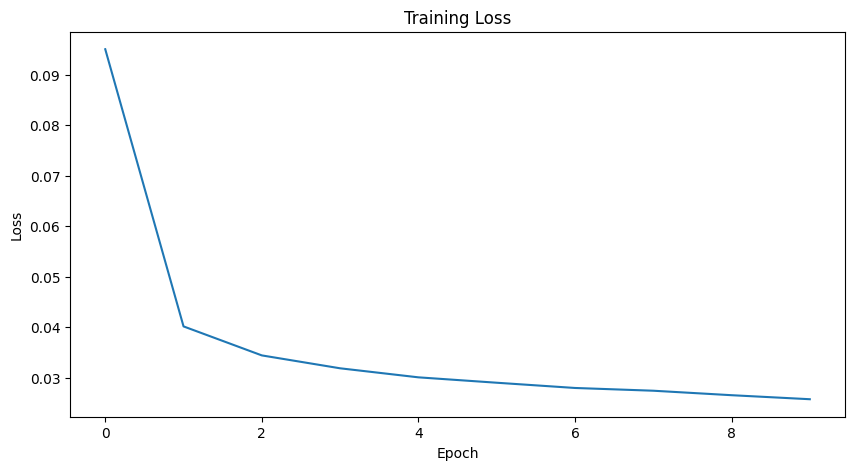

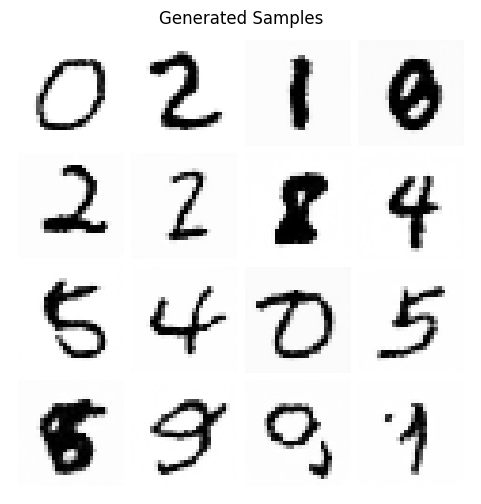

Training with scaled_linear schedule


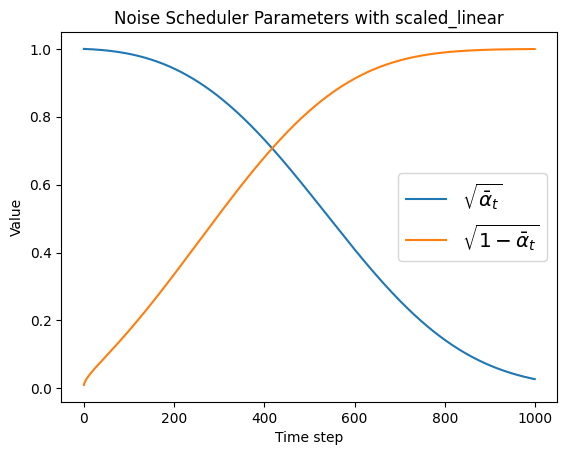

Epoch 1/10, Avg Loss: 0.12957
Epoch 2/10, Avg Loss: 0.05856
Epoch 3/10, Avg Loss: 0.04954
Epoch 4/10, Avg Loss: 0.04561
Epoch 5/10, Avg Loss: 0.04393
Epoch 6/10, Avg Loss: 0.04221
Epoch 7/10, Avg Loss: 0.04102
Epoch 8/10, Avg Loss: 0.04017
Epoch 9/10, Avg Loss: 0.03949
Epoch 10/10, Avg Loss: 0.03894


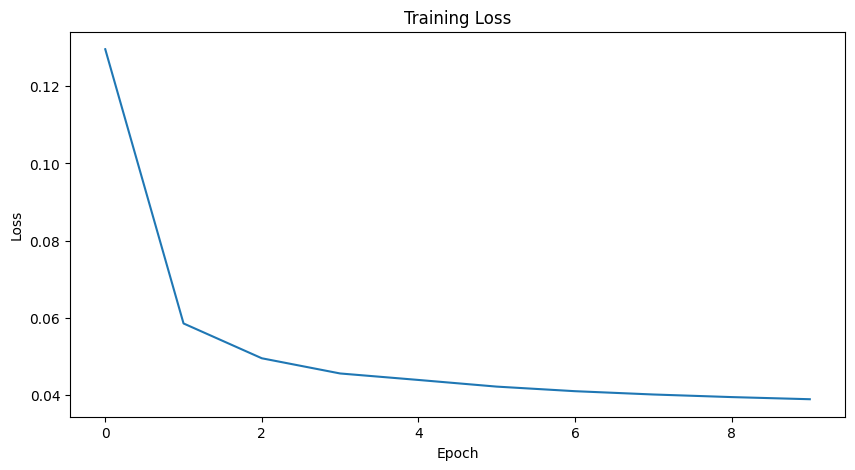

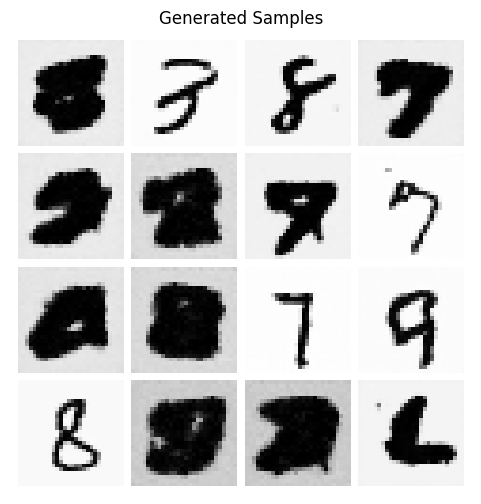

Training with squaredcos_cap_v2 schedule


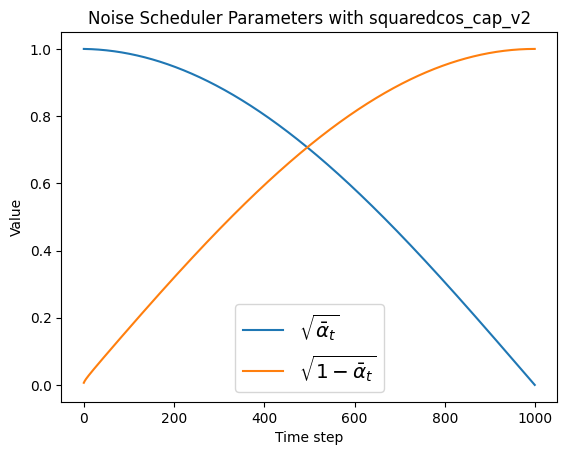

Epoch 1/10, Avg Loss: 0.13730
Epoch 2/10, Avg Loss: 0.06390
Epoch 3/10, Avg Loss: 0.05527
Epoch 4/10, Avg Loss: 0.05172
Epoch 5/10, Avg Loss: 0.04893
Epoch 6/10, Avg Loss: 0.04734
Epoch 7/10, Avg Loss: 0.04597
Epoch 8/10, Avg Loss: 0.04523
Epoch 9/10, Avg Loss: 0.04474
Epoch 10/10, Avg Loss: 0.04400


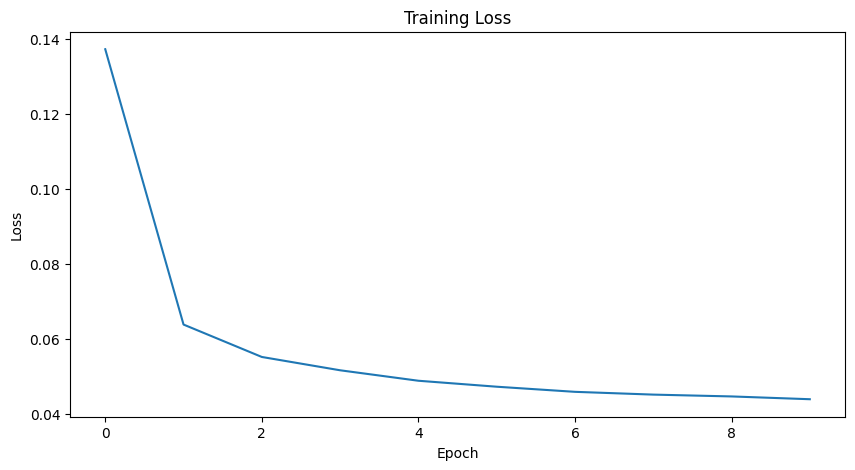

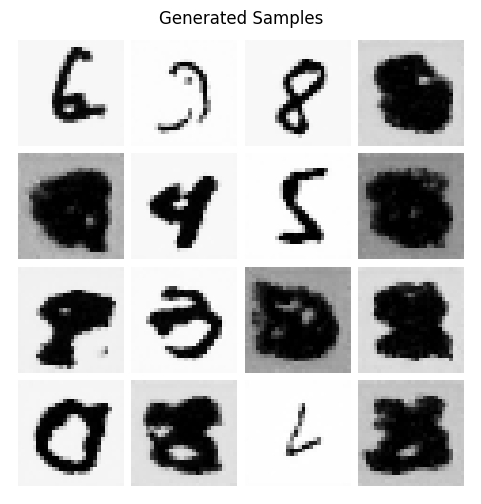

Training with sigmoid schedule


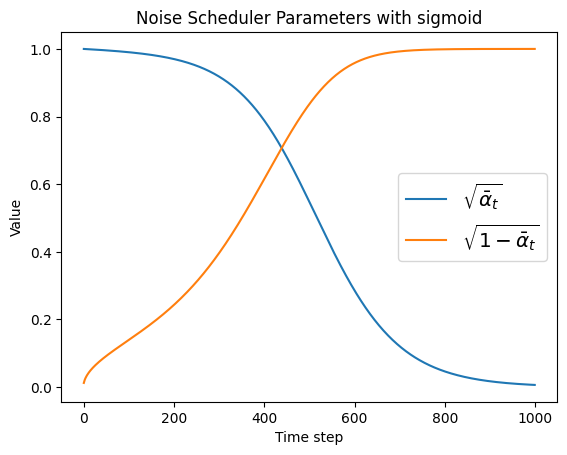

Epoch 1/10, Avg Loss: 0.12789
Epoch 2/10, Avg Loss: 0.05788
Epoch 3/10, Avg Loss: 0.05034
Epoch 4/10, Avg Loss: 0.04699
Epoch 5/10, Avg Loss: 0.04421
Epoch 6/10, Avg Loss: 0.04278
Epoch 7/10, Avg Loss: 0.04216
Epoch 8/10, Avg Loss: 0.04144
Epoch 9/10, Avg Loss: 0.04021
Epoch 10/10, Avg Loss: 0.04006


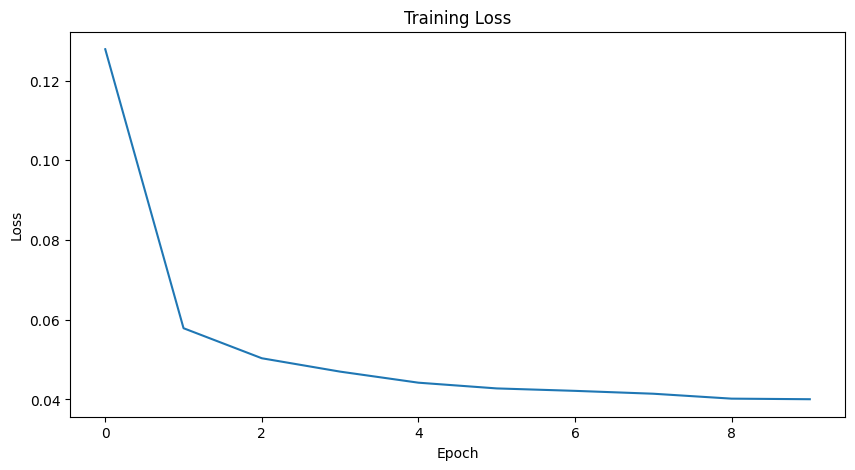

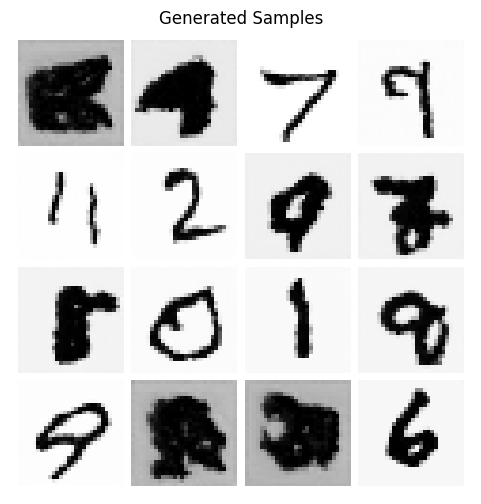

In [ ]:
for schedule in beta_schedules:
    print(f"Training with {schedule} schedule")

    scheduler_kwargs = {
        "beta_schedule": schedule,
        "num_train_timesteps": 1000
    }

    plot_noise(scheduler_kwargs)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")


In [ ]:
# Run hyperparameter tuning with Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)
torch.save(
                study.best_params,
                "/content/drive/MyDrive/Diffusion/ddpm_best_parameters_20trials.pt"
            )
print("Best hyperparameters:", study.best_params)


[I 2025-06-08 16:55:23,141] A new study created in memory with name: no-name-1c3a0428-8560-4c95-a6dc-1d0d5f83dbd8
[I 2025-06-08 16:55:26,069] Trial 0 finished with value: 0.8846594637090509 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 1.2208978106362772e-05, 'beta_end': 0.038103763525795545, 'lr': 9.699609824934948e-05}. Best is trial 0 with value: 0.8846594637090509.
[I 2025-06-08 16:55:28,995] Trial 1 finished with value: 0.5691005641763861 and parameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.0007758723177775468, 'beta_end': 0.04533181927799606, 'lr': 0.0002088727760958186}. Best is trial 1 with value: 0.5691005641763861.
[I 2025-06-08 16:55:31,826] Trial 2 finished with value: 0.9952008290724321 and parameters: {'beta_schedule': 'scaled_linear', 'beta_start': 0.0002681767385776806, 'beta_end': 0.16012811198850238, 'lr': 7.027922778964147e-05}. Best is trial 1 with value: 0.5691005641763861.
[I 2025-06-08 16:55:34,673] Trial 3 finished with value: 0.776209

Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.00014943600232321147, 'beta_end': 0.08302639649349275, 'lr': 0.00034203432394422926}


In [ ]:
file_path = "/content/drive/MyDrive/Diffusion/ddpm_best_parameters_20trials.pt"

best_params = torch.load(file_path)

print("Best parameters:", best_params)


Best parameters: {'beta_schedule': 'squaredcos_cap_v2', 'beta_start': 0.00015064770460850388, 'beta_end': 0.07062676916106778, 'lr': 0.0008923503813371513}


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/20, Avg Loss: 0.07629
Epoch 2/20, Avg Loss: 0.04868
Epoch 3/20, Avg Loss: 0.04542
Epoch 4/20, Avg Loss: 0.04326
Epoch 5/20, Avg Loss: 0.04259
Epoch 6/20, Avg Loss: 0.04148
Epoch 7/20, Avg Loss: 0.04073
Epoch 8/20, Avg Loss: 0.04052
Epoch 9/20, Avg Loss: 0.03994
Epoch 10/20, Avg Loss: 0.03967
Epoch 11/20, Avg Loss: 0.03937
Epoch 12/20, Avg Loss: 0.03915
Epoch 13/20, Avg Loss: 0.03890
Epoch 14/20, Avg Loss: 0.03863
Epoch 15/20, Avg Loss: 0.03845
Epoch 16/20, Avg Loss: 0.03837
Epoch 17/20, Avg Loss: 0.03834
Epoch 18/20, Avg Loss: 0.03841
Epoch 19/20, Avg Loss: 0.03841
Epoch 20/20, Avg Loss: 0.03824


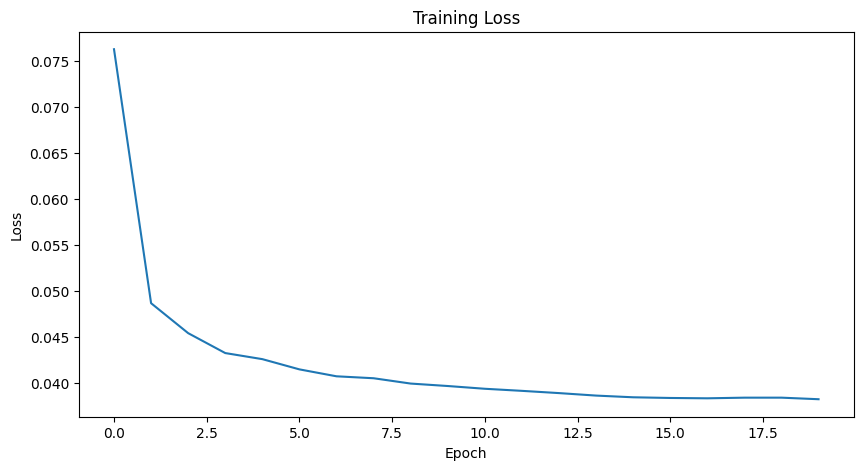

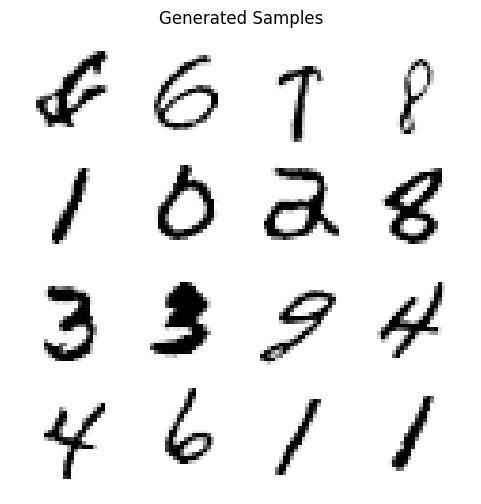

In [ ]:

trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


Best hyperparameters: {'beta_schedule': 'sigmoid', 'beta_start': 0.00014943600232321147, 'beta_end': 0.08302639649349275, 'lr': 0.00034203432394422926}
Epoch 1/20, Avg Loss: 0.07720
Epoch 2/20, Avg Loss: 0.04933
Epoch 3/20, Avg Loss: 0.04555
Epoch 4/20, Avg Loss: 0.04394
Epoch 5/20, Avg Loss: 0.04275
Epoch 6/20, Avg Loss: 0.04180
Epoch 7/20, Avg Loss: 0.04095
Epoch 8/20, Avg Loss: 0.04035
Epoch 9/20, Avg Loss: 0.04010
Epoch 10/20, Avg Loss: 0.03946
Epoch 11/20, Avg Loss: 0.03953
Epoch 12/20, Avg Loss: 0.03914
Epoch 13/20, Avg Loss: 0.03901
Epoch 14/20, Avg Loss: 0.03881
Epoch 15/20, Avg Loss: 0.03876
Epoch 16/20, Avg Loss: 0.03851
Epoch 17/20, Avg Loss: 0.03844
Epoch 18/20, Avg Loss: 0.03838
Epoch 19/20, Avg Loss: 0.03815
Epoch 20/20, Avg Loss: 0.03768


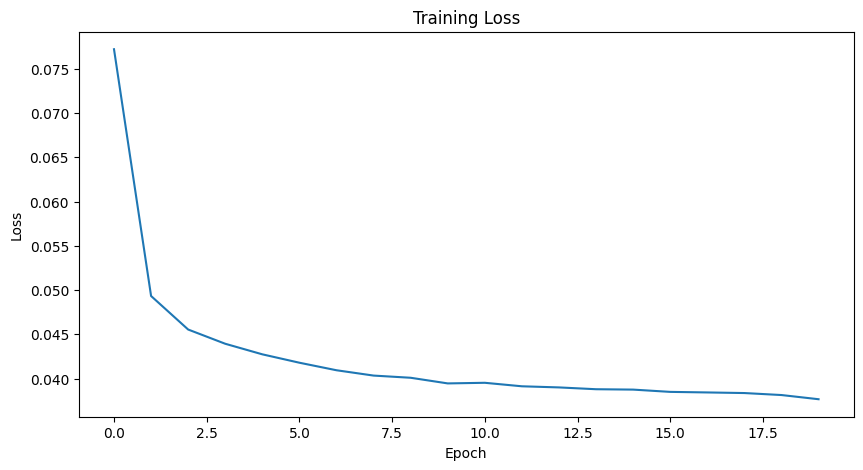

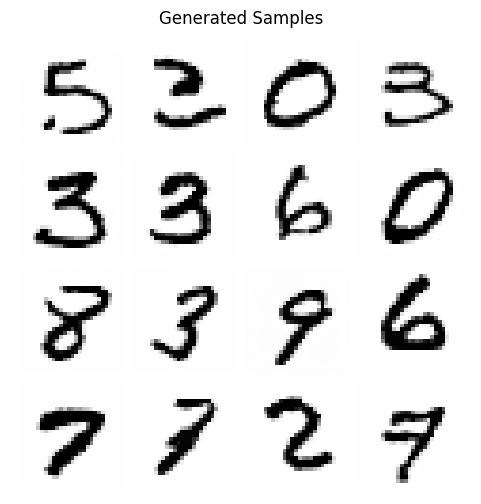

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": best_params["beta_schedule"],
    "beta_start": best_params["beta_start"],
    "beta_end": best_params["beta_end"],
    "num_train_timesteps": 1000
}, lr=best_params["lr"])
print("Best hyperparameters:", study.best_params)

trainer.train(train_dataloader, epochs=20)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


Using device: cpu


/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch 1/5, Avg Loss: 0.07780
Epoch 2/5, Avg Loss: 0.04864
Epoch 3/5, Avg Loss: 0.04563
Epoch 4/5, Avg Loss: 0.04375
Epoch 5/5, Avg Loss: 0.04245


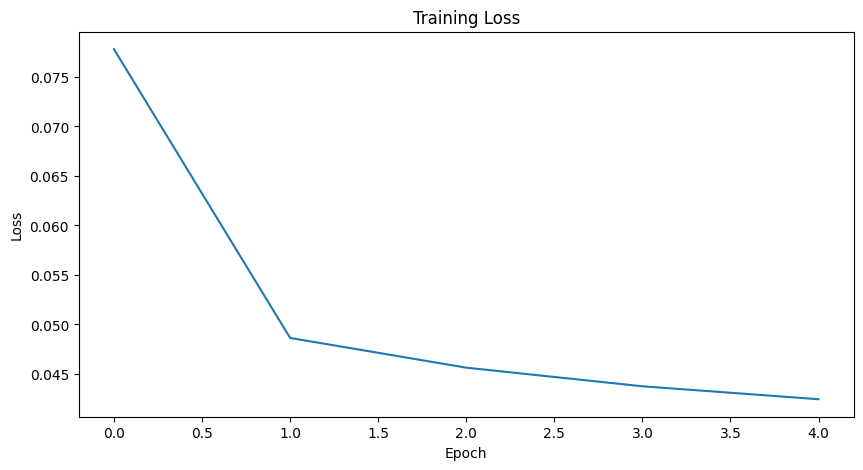

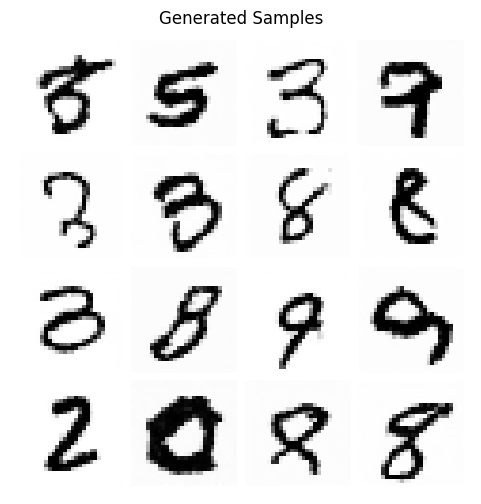

In [ ]:
trainer = DiffusionTrainer(device=device, scheduler_kwargs={
    "beta_schedule": "squaredcos_cap_v2",
    "beta_start": 0.0005855328198419126,
    "beta_end": 0.1933063438151951,
    "num_train_timesteps": 1000
}, lr=0.0008040422614843219)

trainer.train(train_dataloader, epochs=5)

samples = trainer.sample(num_samples=16)
grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

plt.figure(figsize=(6, 6))
plt.title("Generated Samples")
plt.imshow(grid[0], cmap='Greys')
plt.axis('off')
plt.show()


#trying cats

In [ ]:


class CatDiffusionTrainer:
    """
    A class encapsulating the training and sampling procedures of a Denoising Diffusion Probabilistic Model (DDPM).

    This class implements:
    - Forward diffusion process using a noise scheduler (q(x_t | x_0))
    - Training of a UNet neural network to predict added noise at any timestep
    - Sampling procedure from pure noise using the learned denoising model

    Attributes:
        model: The UNet2DModel that predicts noise from noised inputs
        noise_scheduler: A scheduler managing noise levels at each timestep
        optimizer: Optimizer for model training
        device: Device on which model and data are placed
    """
    def __init__(self, device, scheduler_kwargs=None, lr=1e-4):
        """
        Initialize the trainer with model, scheduler, and optimizer.

        Args:
            device: Torch device ("cuda" or "cpu")
            scheduler_kwargs: Dictionary of keyword arguments to customize the DDPMScheduler.
                Accepts keys such as:
                    - beta_schedule (str): e.g., "linear", "scaled_linear", "squaredcos_cap_v2"
                    - beta_start (float): Initial beta value for linear schedules
                    - beta_end (float): Final beta value for linear schedules
                    - num_train_timesteps (int): Total number of diffusion steps
            lr: Learning rate for the optimizer
        """
        self.device = device
        self.model = UNet2DModel(
            sample_size=128,
            in_channels=3,
            out_channels=3,
            layers_per_block=2,
            block_out_channels=(32, 64, 128),
            down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D"),
            up_block_types=("AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
        ).to(device)

        if scheduler_kwargs is None:
            scheduler_kwargs = {
                "beta_schedule": "squaredcos_cap_v2",
                "num_train_timesteps": 1000
            }

        self.noise_scheduler = DDPMScheduler(**scheduler_kwargs)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, dataloader, epochs):
        """
        Train the diffusion model to predict noise added during forward process.

        Args:
            dataloader: DataLoader providing training batches of clean images
            epochs: Number of passes through the training dataset
        """
        self.model.train()
        losses = []
        for epoch in range(epochs):
            epoch_losses = []
            for i, (batch, _) in enumerate(dataloader):
                if i>=50:
                  break
                batch = batch.to(self.device)
                timesteps = torch.randint(
                    0, self.noise_scheduler.num_train_timesteps,
                    (batch.size(0),), device=self.device
                ).long()

                noise = torch.randn_like(batch)
                noisy_batch = self.noise_scheduler.add_noise(batch, noise, timesteps)

                noise_pred = self.model(noisy_batch, timesteps).sample
                loss = nn.functional.mse_loss(noise_pred, noise)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                epoch_losses.append(loss.item())

            avg_loss = sum(epoch_losses) / len(epoch_losses)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {avg_loss:.5f}")

            torch.save(
                self.model.state_dict(),
                f"/content/drive/MyDrive/Diffusion/ddpm_{epoch+1}ep_{self.noise_scheduler.config.beta_schedule}_cat_generator.pt"
            )

        plt.figure(figsize=(10, 5))
        plt.plot(losses)
        plt.title("Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.show()

    def sample(self, num_samples=16):
        """
        Generate images by reversing the diffusion process starting from noise.

        Args:
            num_samples: Number of images to generate

        Returns:
            A batch of generated images scaled to [0, 1] for visualization
        """
        self.model.eval()
        img = torch.randn(num_samples, 3, 128, 128, device=self.device)
        for t in self.noise_scheduler.timesteps:
            with torch.no_grad():
                pred_noise = self.model(img, t).sample
            img = self.noise_scheduler.step(pred_noise, t, img).prev_sample

        img = (img.clamp(-1, 1) + 1) / 2
        return img


def objective(trial):
    """
    Optuna objective function for hyperparameter tuning of the DDPM.
    Tunes the beta_start, beta_end, and learning rate.
    """
    scheduler_params = {
        "beta_schedule": trial.suggest_categorical("beta_schedule", ["linear", "scaled_linear", "squaredcos_cap_v2", "sigmoid"]),
        "beta_start": trial.suggest_float("beta_start", 1e-5, 1e-3, log=True),
        "beta_end": trial.suggest_float("beta_end", 0.01, 0.2),
        "num_train_timesteps": 1000
    }
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)

    trainer = DiffusionTrainer(device=device, scheduler_kwargs=scheduler_params, lr=lr)
    trainer.model.train()

    losses = []
    for batch, _ in train_dataloader:
        batch = batch.to(device)
        timesteps = torch.randint(0, trainer.noise_scheduler.num_train_timesteps, (batch.size(0),), device=device).long()
        noise = torch.randn_like(batch)
        noisy_batch = trainer.noise_scheduler.add_noise(batch, noise, timesteps)
        noise_pred = trainer.model(noisy_batch, timesteps).sample
        loss = nn.functional.mse_loss(noise_pred, noise)

        trainer.optimizer.zero_grad()
        loss.backward()
        trainer.optimizer.step()

        losses.append(loss.item())
        if len(losses) > 10:
            break

    return sum(losses) / len(losses)

def plot_noise(scheduler_kwargs=None):
    if scheduler_kwargs is None:
        scheduler_kwargs = {}

    # Initialize the noise scheduler
    noise_scheduler = DDPMScheduler(**scheduler_kwargs)
    schedule_name = scheduler_kwargs.get("beta_schedule", "Unknown Schedule")

    # Plot the square root of alphas_cumprod
    plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"$\sqrt{\bar{\alpha}_t}$")

    # Plot the square root of (1 - alphas_cumprod)
    plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{1 - \bar{\alpha}_t}$")

    # Add labels and legend
    plt.xlabel('Time step')
    plt.ylabel('Value')
    if schedule_name:
        plt.title(f'Noise Scheduler Parameters with {schedule_name}')
    else:
        plt.title('Noise Scheduler Parameters')
    plt.legend(fontsize="x-large")

    # Show the plot
    plt.show()

def plot_generated_samples(samples, num_samples=16, title="Generated Samples"):
    """
    Plot a grid of generated samples.

    Args:
        samples: A batch of generated images as a torch tensor.
        num_samples: Number of samples to plot.
        title: Title for the plot.
    """
    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4)

    plt.figure(figsize=(6, 6))
    plt.title("Generated Samples")
    plt.imshow(grid[0], cmap='Greys')
    plt.axis('off')
    plt.show()




In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transforms: resize, convert to tensor, normalize to [-1, 1]
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0)  # scale from [0,1] to [-1,1]
])

# Path to AFHQ-512  dataset
data_path = "/content/drive/MyDrive/Diffusion/Datasets/afhq-512"

# Load dataset
dataset = datasets.ImageFolder(root=data_path, transform=transform)

# Create DataLoader
train_dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Loaded {len(dataset)} images.")

Using device: cuda
Loaded 5558 images.


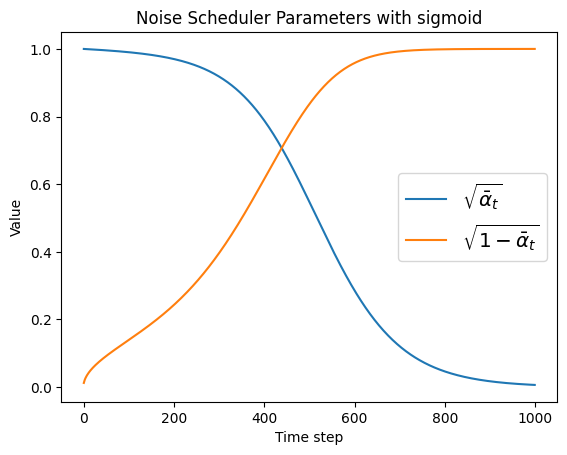

OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 52.12 MiB is free. Process 5609 has 14.69 GiB memory in use. Of the allocated memory 14.13 GiB is allocated by PyTorch, and 445.07 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:

    # Define scheduler kwargs
    scheduler_kwargs = {
        "beta_schedule": "sigmoid",
        "num_train_timesteps": 1000
    }

    # Plot the noise schedule
    plot_noise(scheduler_kwargs)

    # Initialize the DiffusionTrainer
    trainer = CatDiffusionTrainer(device=device, scheduler_kwargs=scheduler_kwargs, lr=1e-4)

    # Train the model for 5 epochs
    trainer.train(train_dataloader, epochs=10)

    plot_generated_samples(trainer.sample(num_samples=16), title=f"Generated Samples with {schedule} schedule")